# EMBEDDING + ADDITION NN

## 1. Import libraries

This section imports all required libraries for data processing, model building, and evaluation.


In [24]:
# Import libraries
import os, random, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)

##2. Fix the random seed across all libraries.

Ensuring reproducibility

In [25]:
# Seed = 42

seed = 42
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
tf.keras.utils.set_random_seed(seed)

print("Seed fixed:", seed)

Seed fixed: 42


##3. Load Dataset
The dataset is loaded and column names are cleaned.

In [26]:
# Import dataset

df = pd.read_csv("/content/digital_marketing_campaign_dataset.csv")
df.columns = df.columns.str.strip()

In [27]:
# Target

target = "Conversion"

Remove unnecessary columns

In [28]:
# Drop usesless/leakage

df = df.drop(columns=["CustomerID", "ConversionRate"], errors="ignore")

##4. Feature Engineering

In [29]:
# Define features
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

if target in numerical_cols:
    numerical_cols.remove(target)

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Gender', 'CampaignChannel', 'CampaignType', 'AdvertisingPlatform', 'AdvertisingTool']
Numerical: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']


##5. Train / Validation / Test Split
Dataset is split into:
- 70% Training
- 15% Validation
- 15% Testing


In [30]:
# Split (70 / 15 / 15)
X = df.drop(columns=[target])
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("\n Distribution of y_test:")
print(y_test.value_counts())

print("\n Distribution of y_test (%):")
print(y_test.value_counts(normalize=True))

print("\n")

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)



 Distribution of y_test:
Conversion
1    1052
0     148
Name: count, dtype: int64

 Distribution of y_test (%):
Conversion
1    0.876667
0    0.123333
Name: proportion, dtype: float64


Train: (5600, 17)
Val: (1200, 17)
Test: (1200, 17)


##6. Encode Categorical Variables
Objective: apply LabelEncoder to transform categorical values into numeric format

In [31]:
# Encode categorical
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

    label_encoders[col] = le


##7. Scale Numerical Features
StandardScaler: normalize numerical features

In [32]:
# Scale numerical(no leakage)
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])



##8. Model Architecture
Key components
- Embedding layers for cateogrical variables
- Concatentation with numerical inputs
- Fully connected laters (MLP)

In [33]:
# Build model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model

inputs = []
embeddings = []

In [34]:
# Categorical embeddings
for col in categorical_cols:
    inp = Input(shape=(1,), name=col)

    vocab_size = X_train[col].nunique() + 1
    embed_dim = min(50, vocab_size // 2)

    emb = Embedding(vocab_size, embed_dim)(inp)
    emb = Flatten()(emb)

    inputs.append(inp)
    embeddings.append(emb)

###Architecture
- Dense(128) + Droupout
- Dense(64) + Dropout
- Dense(32)
- Output layer (Sigmoid)

In [35]:
# Numerical input
num_input = Input(shape=(len(numerical_cols),), name="numerical")
inputs.append(num_input)


In [36]:
# Concat
x = Concatenate()(embeddings + [num_input])

##9. Model Training
We train the model with
- Loss: binary_crossentropy
- Optimizer: Adam
- Early stopping to prevent overfitting

In [37]:
# MLP
x = BatchNormalization()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(32, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=inputs, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Gender (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CampaignChannel     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CampaignType        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AdvertisingPlatform │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AdvertisingTool     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 1)      │          3 │ Gender[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 3)      │         18 │ CampaignChannel[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 2)      │         10 │ CampaignType[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 1)      │          2 │ AdvertisingPlatf… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 1)      │          2 │ AdvertisingTool[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 1)         │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 3)         │          0 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 2)         │          0 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 1)         │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 1)         │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical           │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 20)        │          0 │ flatten_5[0][0],  │
│ (Concatenate)       │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ numerical[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 13,172 (51.45 KB)

 Trainable params: 13,132 (51.30 KB)

 Non-trainable params: 40 (160.00 B)

In [38]:
# Prepare input dict
def prepare_inputs(X):
    data = {col: X[col].values for col in categorical_cols}
    data["numerical"] = X[numerical_cols].values
    return data

train_inputs = prepare_inputs(X_train)
val_inputs = prepare_inputs(X_val)
test_inputs = prepare_inputs(X_test)


In [39]:
# Train
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_inputs,
    y_train,
    validation_data=(val_inputs, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8696 - loss: 0.3774 - val_accuracy: 0.8767 - val_loss: 0.3434
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8813 - loss: 0.3226 - val_accuracy: 0.8842 - val_loss: 0.3376
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8850 - loss: 0.3173 - val_accuracy: 0.8833 - val_loss: 0.3348
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8871 - loss: 0.3111 - val_accuracy: 0.8850 - val_loss: 0.3305
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8913 - loss: 0.3012 - val_accuracy: 0.8833 - val_loss: 0.3301
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8884 - loss: 0.3015 - val_accuracy: 0.8867 - val_loss: 0.3279
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8907 - loss: 0.2954 - val_accuracy: 0.8833 - val_loss: 0.3293
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8929 - loss: 0.2930 - val_accuracy: 

## 10. Model Evaluation
- AUC (Area Under Curve)
- F1-score

In [40]:
#Evaluate
y_pred_prob = model.predict(test_inputs)
y_pred = (y_pred_prob > 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("F1:", f1_score(y_test, y_pred))


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
AUC: 0.7463904018086527
F1: 0.936247723132969


##11. Confusion Matrix
Visualizes classification performance
- True Positive
- False Positive
- True Negative
- False Negative

Confusion Matrix:
[[  32  116]
 [  24 1028]]

TN (True Negative): 32
FP (False Positive): 116
FN (False Negative): 24
TP (True Positive): 1028


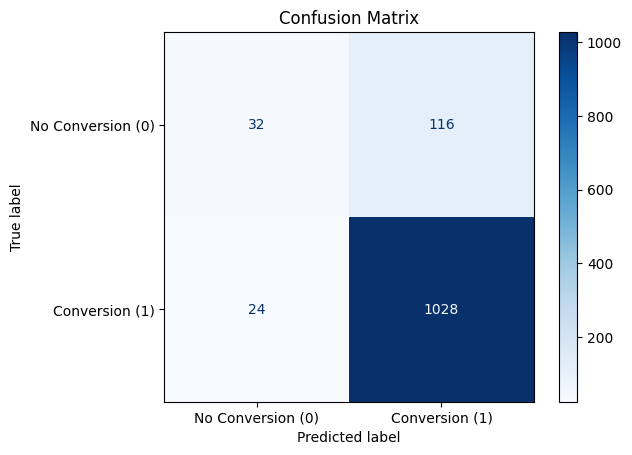

In [21]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTN (True Negative): {tn}")
print(f"FP (False Positive): {fp}")
print(f"FN (False Negative): {fn}")
print(f"TP (True Positive): {tp}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Conversion (0)", "Conversion (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()



Accuracy, Precision, Recal, F1

In [41]:
# Accuracy, Precision, Recal, F1
total = cm.sum()

print("\nRates:")
print(f"Accuracy: {(tp + tn) / total:.4f}")
print(f"Precision: {tp / (tp + fp):.4f}")
print(f"Recall: {tp / (tp + fn):.4f}")



Rates:
Accuracy: 0.8833
Precision: 0.8986
Recall: 0.9772


##12. ROC Curve
Shows trade-off between:
- False Positive Rate
- True Positive Rate

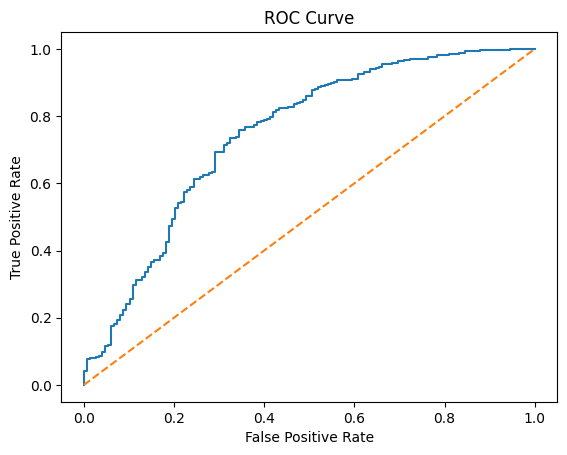

In [42]:
# Roc curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

##13. Training Curve
We plot
- Training loss
- Validation loss
to monior model performance and overfitting.

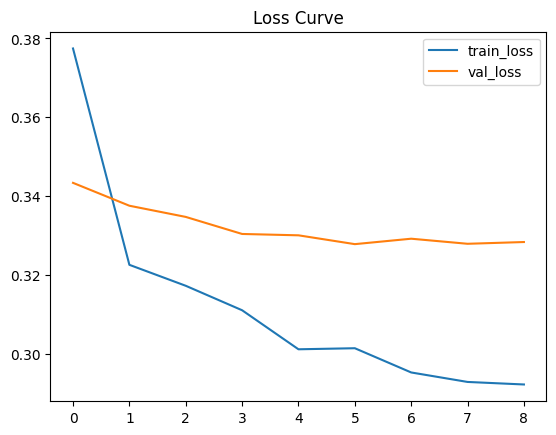

In [43]:
# Training curves
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.show()